In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
%matplotlib inline 

In [2]:
df=pd.read_csv("/kaggle/input/heart-disease-data/framingham.csv")
print(f"Data Shape: {df.shape}")
print(f"Checkout Null Values: {df.isnull().sum()}")
print(f"Dataset Info: {df.info()}")
print(f"Dataset Description: {df.describe()}")
display(df.head())

Data Shape: (4240, 16)
Checkout Null Values: male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   di

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
median_cols = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']
for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

mode_cols = ['education', 'BPMeds']
for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [4]:
df = df.rename(columns={
    'male': 'Gender',
    'age': 'Age',
    'education': 'Education',
    'currentSmoker': 'Current_Smoker',
    'cigsPerDay': 'Cigarettes_Per_Day',
    'BPMeds': 'BP_Medication',
    'prevalentStroke': 'Prevalent_Stroke',
    'prevalentHyp': 'Prevalent_Hypertension',
    'diabetes': 'Diabetes',
    'totChol': 'Total_Cholesterol',
    'sysBP': 'Systolic_BP',
    'diaBP': 'Diastolic_BP',
    'BMI': 'BMI',
    'heartRate': 'Heart_Rate',
    'glucose': 'Glucose',
    'TenYearCHD': 'Ten_Year_CHD'
})

df.columns = df.columns.str.replace(' ', '_')
df.head()

,Gender,Age,Education,Current_Smoker,Cigarettes_Per_Day,BP_Medication,Prevalent_Stroke,Prevalent_Hypertension,Diabetes,Total_Cholesterol,Systolic_BP,Diastolic_BP,BMI,Heart_Rate,Glucose,Ten_Year_CHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


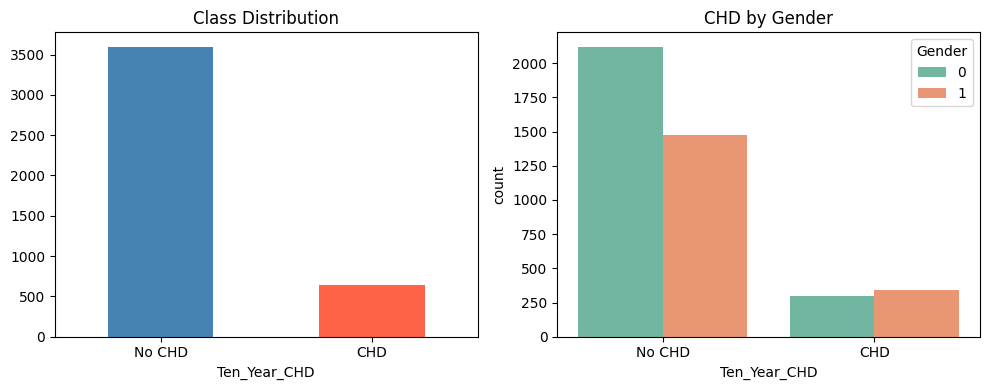

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Ten_Year_CHD'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['No CHD', 'CHD'], rotation=0)
sns.countplot(data=df, x='Ten_Year_CHD', hue='Gender', ax=axes[1], palette='Set2')
axes[1].set_title('CHD by Gender')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No CHD', 'CHD'])
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

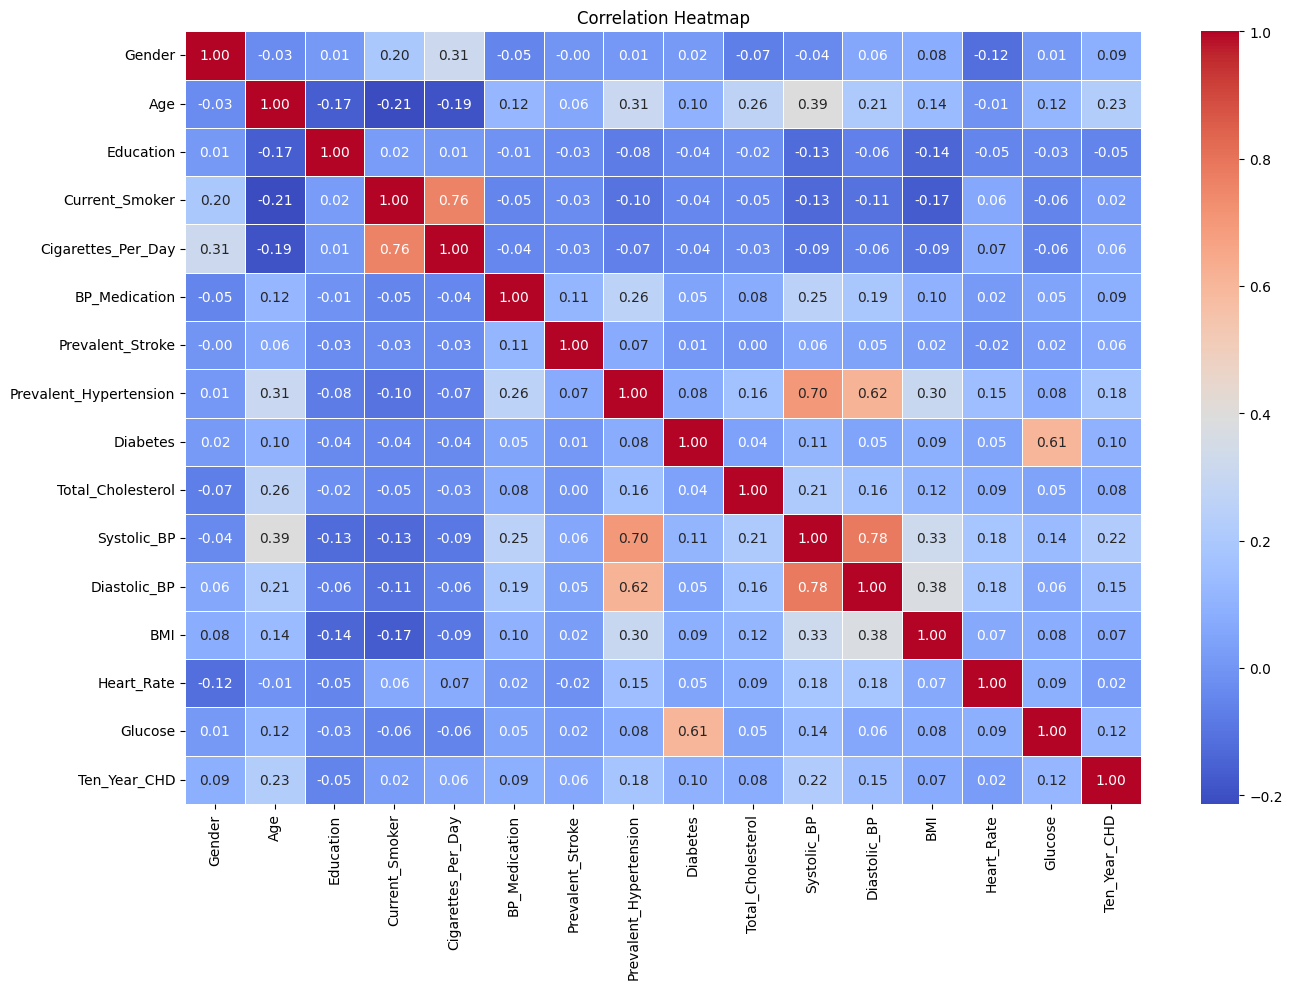

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

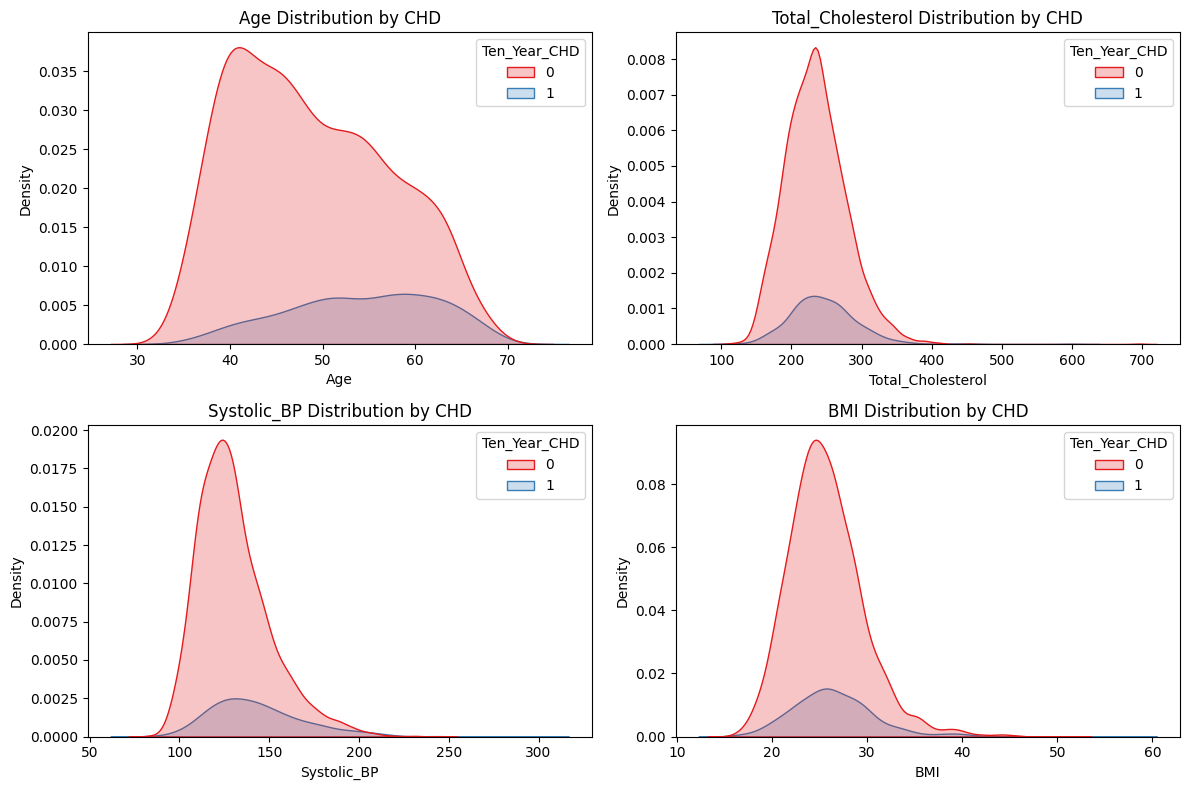

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ['Age', 'Total_Cholesterol', 'Systolic_BP', 'BMI']):
    sns.kdeplot(data=df, x=col, hue='Ten_Year_CHD', ax=ax, fill=True, palette='Set1')
    ax.set_title(f'{col} Distribution by CHD')
plt.tight_layout()
plt.savefig('distributions.png', dpi=300, bbox_inches='tight')
plt.show()

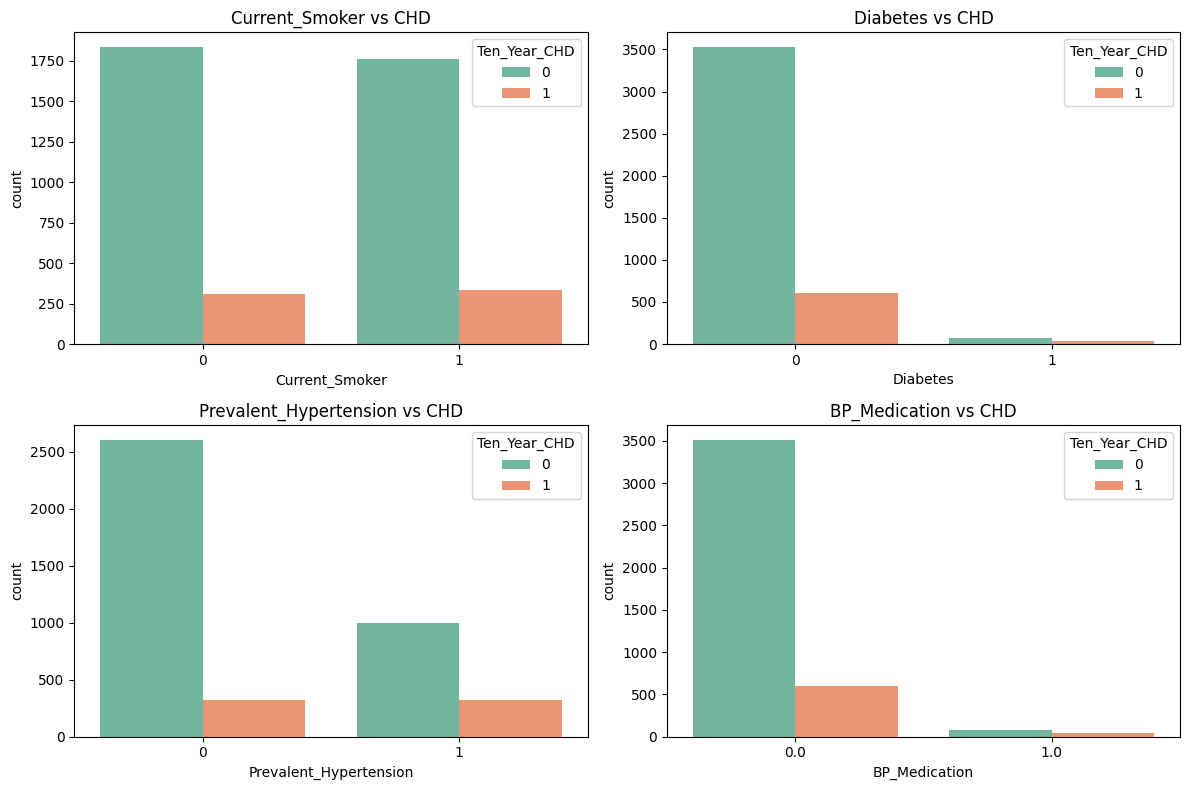

In [8]:
cat_cols = ['Current_Smoker', 'Diabetes', 'Prevalent_Hypertension', 'BP_Medication']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # flatten 2D array to 1D for easy looping

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue='Ten_Year_CHD', ax=ax, palette='Set2')
    ax.set_title(f'{col} vs CHD')

plt.tight_layout()
plt.savefig('categorical_features.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']

In [10]:
df_majority = df[df['Ten_Year_CHD'] == 0]
df_minority = df[df['Ten_Year_CHD'] == 1]

df_minority_upsampled = resample(df_minority,
                                  replace=True,
                                  n_samples=len(df_majority),
                                  random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
print(df_balanced['Ten_Year_CHD'].value_counts())


Ten_Year_CHD
0    3596
1    3596
Name: count, dtype: int64


In [11]:
X = df_balanced.drop('Ten_Year_CHD', axis=1)
y = df_balanced['Ten_Year_CHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")


Train size: (5753, 16)
Test size: (1439, 16)


In [13]:
from xgboost import XGBClassifier

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='logloss',
    device='cuda'
)

xgb_cv = cross_val_score(xgb, X_train, y_train, cv=skf, scoring='accuracy')
print(f"CV Scores : {xgb_cv}")
print(f"CV Mean   : {xgb_cv.mean():.4f}")
print(f"CV Std    : {xgb_cv.std():.4f}")

CV Scores : [0.828125   0.85069444 0.86979167 0.8573913  0.83478261 0.82086957
 0.84869565 0.85217391 0.84       0.82782609]
CV Mean   : 0.8430
CV Std    : 0.0146


In [14]:
xgb.fit(X_train, y_train)
y_pred_knn = xgb.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_pre = precision_score(y_test, y_pred_knn)
knn_rec = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

print(f"Accuracy  : {knn_acc:.4f}")
print(f"Precision : {knn_pre:.4f}")
print(f"Recall    : {knn_rec:.4f}")
print(f"F1-Score  : {knn_f1:.4f}")
print(f"ROC-AUC   : {knn_auc:.4f}")


Accuracy  : 0.8548
Precision : 0.8269
Recall    : 0.8971
F1-Score  : 0.8606
ROC-AUC   : 0.9075


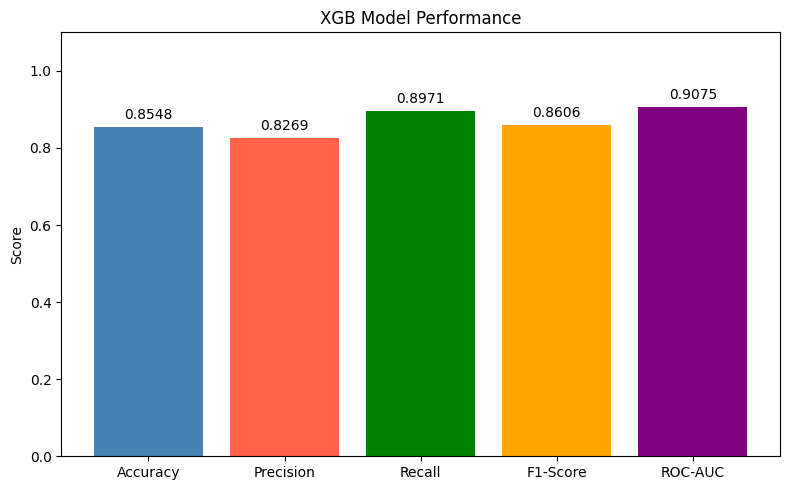

In [15]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [knn_acc, knn_pre, knn_rec, knn_f1, knn_auc]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=['steelblue','tomato','green','orange','purple'])
plt.ylim(0, 1.1)
plt.title('XGB Model Performance')
plt.ylabel('Score')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,f'{val:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('xgb_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

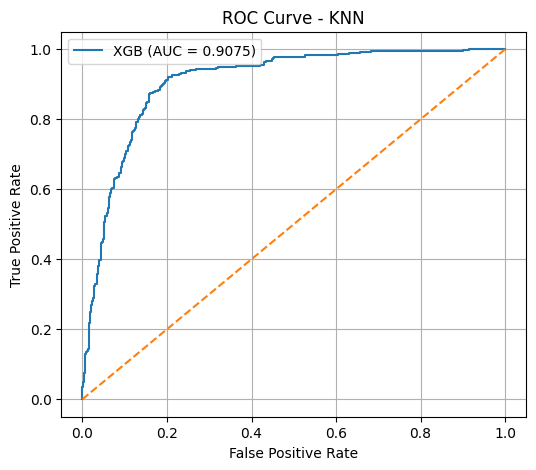

In [16]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"XGB (AUC = {knn_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.grid()

plt.savefig("xgb_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

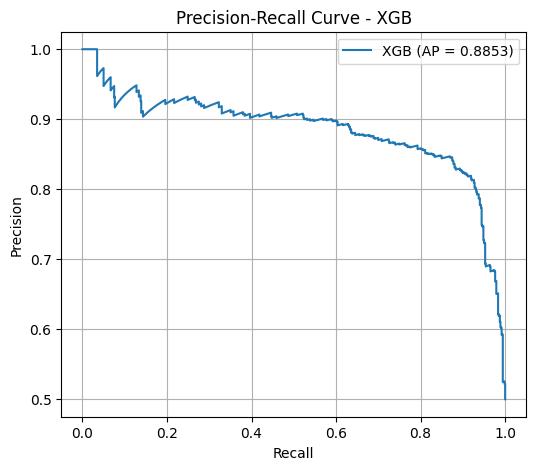

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_prob = xgb.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"XGB (AP = {ap_score:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGB")
plt.legend()
plt.grid()

plt.savefig("xgb_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

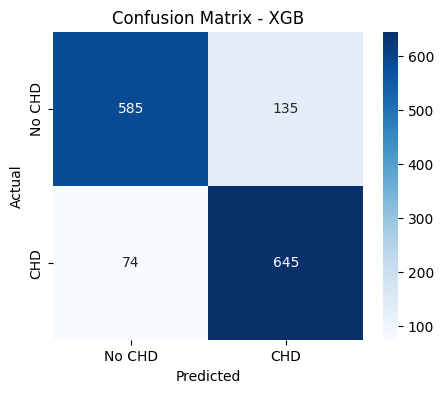

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No CHD", "CHD"],
            yticklabels=["No CHD", "CHD"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGB")

plt.savefig("xgb_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_knn, target_names=["No CHD", "CHD"])
print(report)

              precision    recall  f1-score   support

      No CHD       0.89      0.81      0.85       720
         CHD       0.83      0.90      0.86       719

    accuracy                           0.85      1439
   macro avg       0.86      0.85      0.85      1439
weighted avg       0.86      0.85      0.85      1439



In [20]:
# from sklearn.model_selection import learning_curve
# from tqdm import tqdm
# import threading

# def plot_learning_curve(model, X, y, title):
#     result = {}
    
#     def run():
#         result['output'] = learning_curve(model, X, y, cv=skf, scoring='accuracy',train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)
    
#     thread = threading.Thread(target=run)
#     thread.start()
    
#     with tqdm(total=10, desc=f'Learning Curve {title}', bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}') as pbar:
#         while thread.is_alive():
#             thread.join(timeout=1)
#             pbar.update(0)
    
#     train_sizes, train_scores, val_scores = result['output']
    
#     train_mean = train_scores.mean(axis=1)
#     train_std = train_scores.std(axis=1)
#     val_mean = val_scores.mean(axis=1)
#     val_std = val_scores.std(axis=1)
    
#     plt.figure(figsize=(8, 5))
#     plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
#     plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
#     plt.plot(train_sizes, val_mean, label='Validation Score', color='red')
#     plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
#     plt.title(f'Learning Curve - {title}')
#     plt.xlabel('Training Size')
#     plt.ylabel('Accuracy')
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(f'learning_curve_{title}.png', dpi=300, bbox_inches='tight')
#     plt.show()

# feature_names = df_balanced.drop('Ten_Year_CHD', axis=1).columns
# X_train_df = pd.DataFrame(X_train, columns=feature_names)
# X_test_df = pd.DataFrame(X_test, columns=feature_names)
# plot_learning_curve(lgb, X_train_df, y_train, 'LGB')

In [21]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.model_selection import learning_curve
# import time

# feature_names = df_balanced.drop('Ten_Year_CHD', axis=1).columns
# X_train_df = pd.DataFrame(X_train, columns=feature_names, index=y_train.index)

# start_time = time.time()

# train_sizes, train_scores, val_scores = learning_curve(
#     lgb,
#     X_train_df,
#     y_train,
#     cv=5,
#     n_jobs=-1,
#     train_sizes=np.linspace(0.1, 1.0, 10),
#     scoring='accuracy'
# )

# end_time = time.time()
# elapsed = end_time - start_time
# minutes = int(elapsed // 60)
# seconds = elapsed % 60

# print(f"Learning curve computation took: {minutes} min {seconds:.1f} sec")

# train_mean = np.mean(train_scores, axis=1)
# train_std = np.std(train_scores, axis=1)
# val_mean = np.mean(val_scores, axis=1)
# val_std = np.std(val_scores, axis=1)

# plt.figure(figsize=(10, 6))
# plt.plot(train_sizes, train_mean, 'o-', color='#27ae60', linewidth=2, markersize=6, label='Training Score')
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#27ae60')
# plt.plot(train_sizes, val_mean, 'o-', color='#c0392b', linewidth=2, markersize=6, label='Validation Score')
# plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#c0392b')

# gap = train_mean - val_mean
# for i, (size, g) in enumerate(zip(train_sizes, gap)):
#     if i % 2 == 0:
#         plt.annotate(f'Gap: {g:.3f}', xy=(size, val_mean[i]), xytext=(10, -15), 
#                     textcoords='offset points', fontsize=8, alpha=0.7)

# plt.xlabel('Training Set Size', fontsize=11)
# plt.ylabel('Accuracy Score', fontsize=11)
# plt.title('Learning Curve - LightGBM', fontsize=14, fontweight='bold')
# plt.legend(loc='best')
# plt.grid(True, alpha=0.3, linestyle='--')
# plt.tight_layout()
# plt.savefig('lgb_learning_curve.png', dpi=300, bbox_inches='tight')
# plt.show()

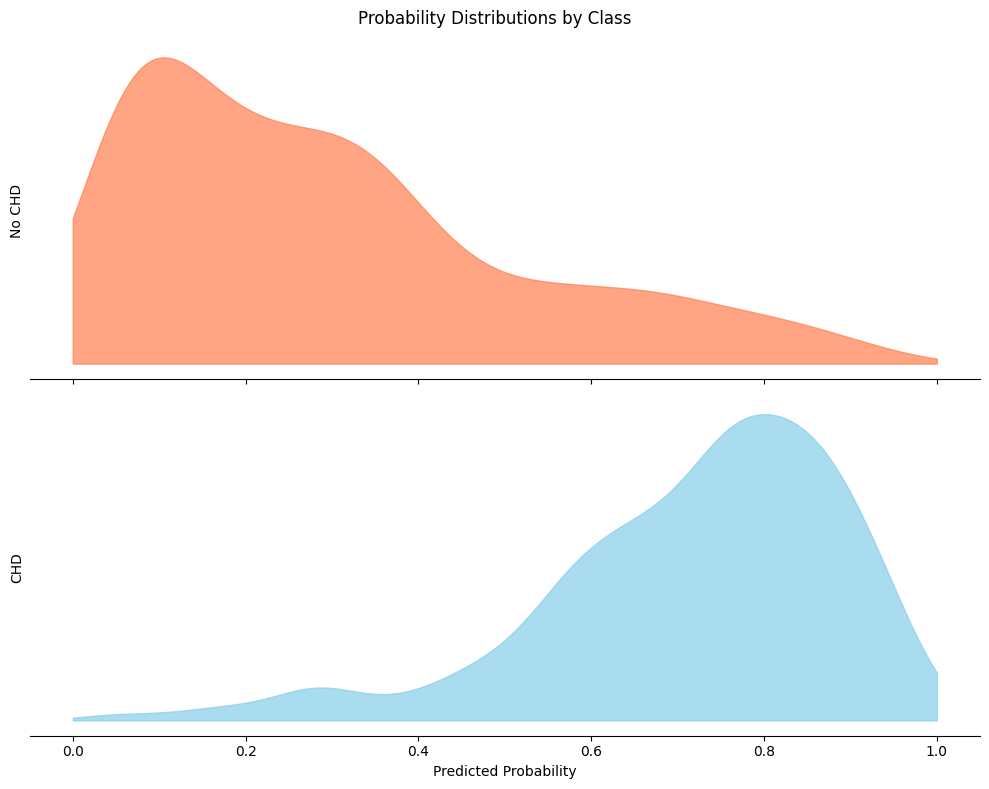

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

y_pred_prob = xgb.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Actual': y_test.values,
    'Probability': y_pred_prob
})

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for idx, (label, actual_val) in enumerate([('No CHD', 0), ('CHD', 1)]):
    subset = results[results['Actual'] == actual_val]['Probability']
    density = gaussian_kde(subset)
    xs = np.linspace(0, 1, 200)
    axes[idx].fill_between(xs, density(xs), alpha=0.7, color=['coral', 'skyblue'][idx])
    axes[idx].set_ylabel(label)
    axes[idx].set_yticks([])
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    axes[idx].spines['left'].set_visible(False)

axes[1].set_xlabel('Predicted Probability')
plt.suptitle('Probability Distributions by Class', y=0.98)
plt.tight_layout()
plt.show()

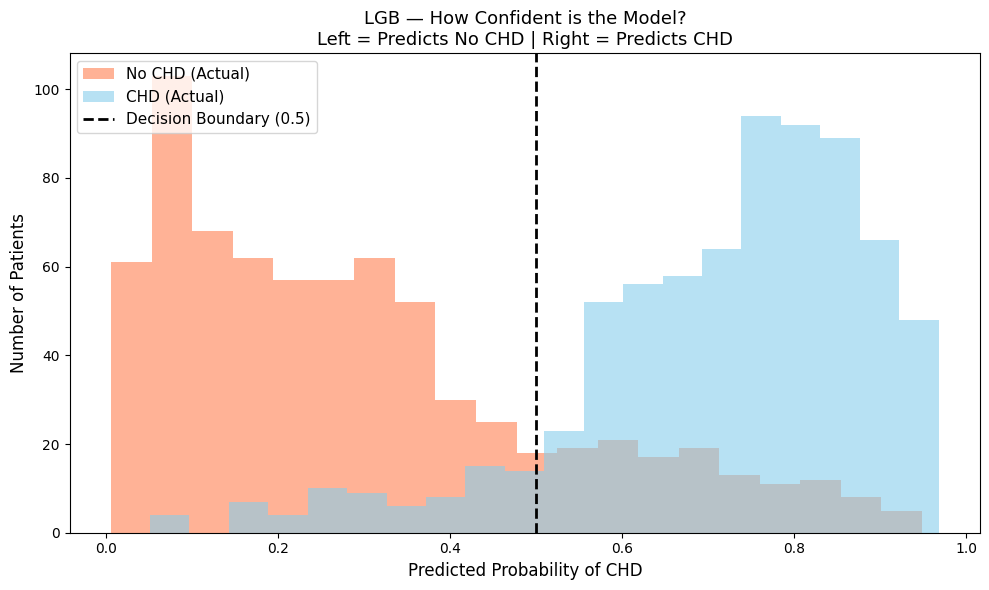

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

no_chd_probs = results[results['Actual'] == 0]['Probability']
chd_probs = results[results['Actual'] == 1]['Probability']

ax.hist(no_chd_probs, bins=20, alpha=0.6, color='coral', label='No CHD (Actual)')
ax.hist(chd_probs, bins=20, alpha=0.6, color='skyblue', label='CHD (Actual)')

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')
ax.set_xlabel('Predicted Probability of CHD', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('LGB — How Confident is the Model?\nLeft = Predicts No CHD | Right = Predicts CHD', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('xgb_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

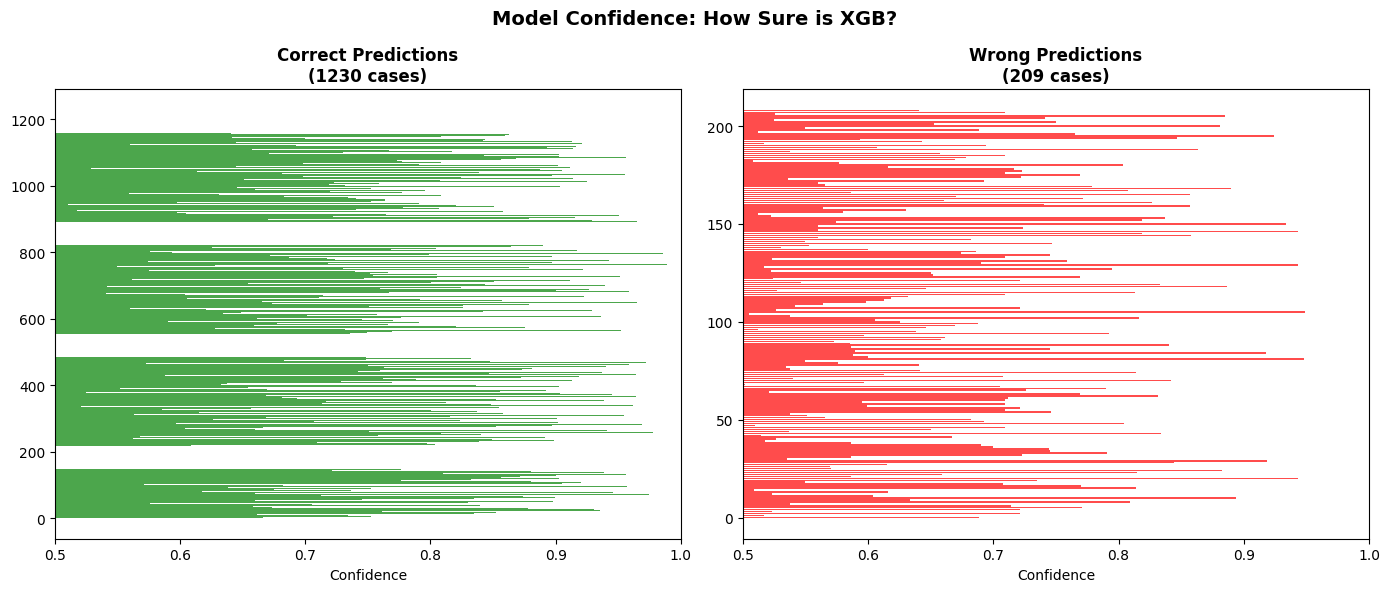

Correct: 1230 (85.5%)
Wrong:   209 (14.5%)


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y_pred_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = xgb.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_pred_prob
})

results['Confidence'] = np.where(results['Probability'] > 0.5, 
                                  results['Probability'], 
                                  1 - results['Probability'])
results['Outcome'] = np.where((results['Actual'] == results['Predicted']), 'Correct', 'Wrong')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

correct = results[results['Outcome'] == 'Correct']
wrong = results[results['Outcome'] == 'Wrong']

axes[0].barh(range(len(correct)), correct['Confidence'], color='green', alpha=0.7)
axes[0].set_title(f'Correct Predictions\n({len(correct)} cases)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_xlim(0.5, 1)

axes[1].barh(range(len(wrong)), wrong['Confidence'], color='red', alpha=0.7)
axes[1].set_title(f'Wrong Predictions\n({len(wrong)} cases)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].set_xlim(0.5, 1)

plt.suptitle('Model Confidence: How Sure is XGB?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Correct: {len(correct)} ({len(correct)/len(results)*100:.1f}%)")
print(f"Wrong:   {len(wrong)} ({len(wrong)/len(results)*100:.1f}%)")

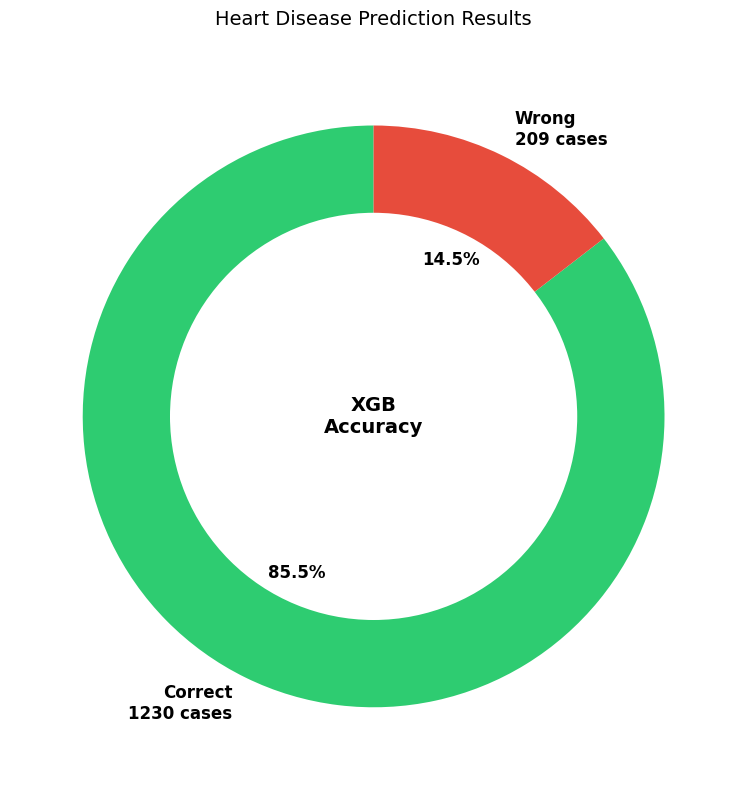

In [25]:
import matplotlib.pyplot as plt

correct = (y_test == y_pred_knn).sum()
wrong = len(y_test) - correct

fig, ax = plt.subplots(figsize=(8, 8))

sizes = [correct, wrong]
colors = ['#2ecc71', '#e74c3c']
labels = [f'Correct\n{correct} cases', f'Wrong\n{wrong} cases']

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, 
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.text(0, 0, 'XGB\nAccuracy', ha='center', va='center', fontsize=14, fontweight='bold')

plt.title('Heart Disease Prediction Results', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

/tmp/ipykernel_336/1035346272.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_summary = results.groupby('Prob_Bucket').agg({


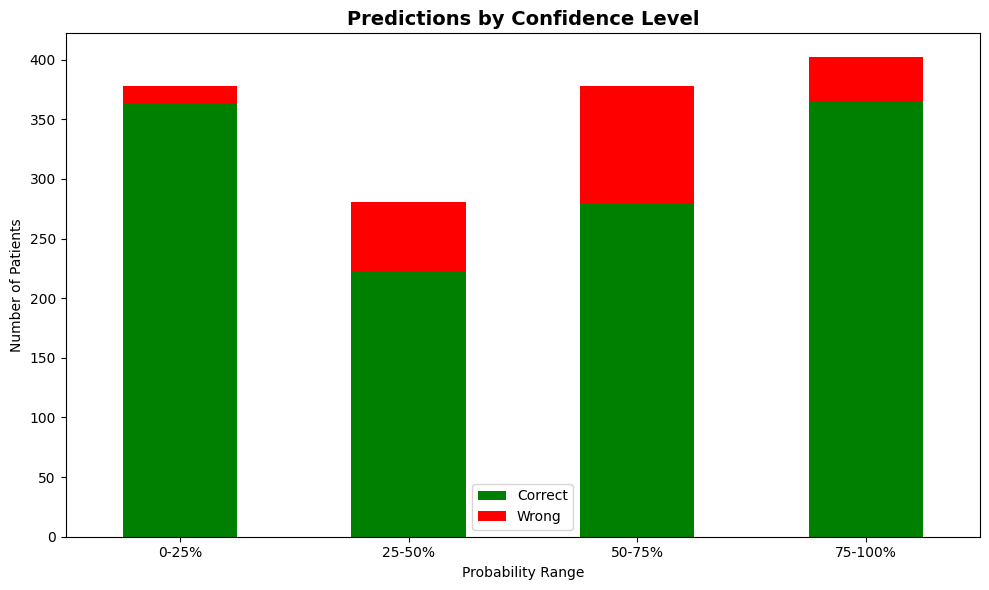

In [26]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_knn,
    'Probability': xgb.predict_proba(X_test)[:, 1]
})

results['Prob_Bucket'] = pd.cut(results['Probability'], 
                                 bins=[0, 0.25, 0.5, 0.75, 1.0],
                                 labels=['0-25%', '25-50%', '50-75%', '75-100%'])

bucket_summary = results.groupby('Prob_Bucket').agg({
    'Actual': 'count',
    'Predicted': lambda x: (x == results.loc[x.index, 'Actual']).sum()
}).rename(columns={'Actual': 'Total', 'Predicted': 'Correct'})

bucket_summary['Wrong'] = bucket_summary['Total'] - bucket_summary['Correct']

bucket_summary[['Correct', 'Wrong']].plot(kind='bar', stacked=True, 
                                           color=['green', 'red'], 
                                           figsize=(10, 6))

plt.title('Predictions by Confidence Level', fontsize=14, fontweight='bold')
plt.xlabel('Probability Range')
plt.ylabel('Number of Patients')
plt.legend(['Correct', 'Wrong'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

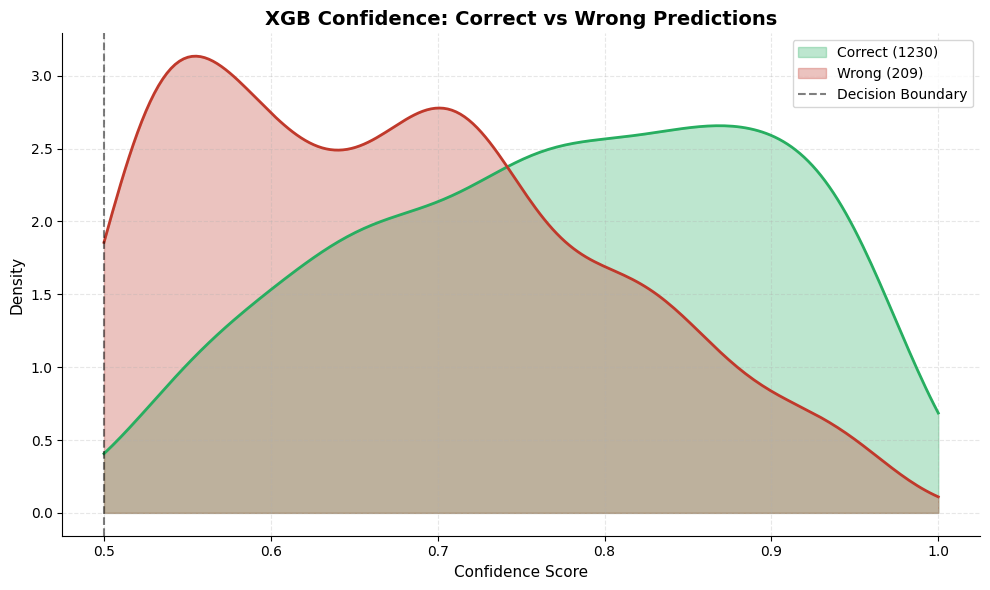

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

y_pred_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = xgb.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_pred_prob
})

results['Confidence'] = np.where(results['Probability'] > 0.5, 
                                  results['Probability'], 
                                  1 - results['Probability'])
results['Outcome'] = np.where(results['Actual'] == results['Predicted'], 'Correct', 'Wrong')

correct = results[results['Outcome'] == 'Correct']
wrong = results[results['Outcome'] == 'Wrong']

fig, ax = plt.subplots(figsize=(10, 6))
xs = np.linspace(0.5, 1, 200)

if len(correct) > 1:
    kde_correct = gaussian_kde(correct['Confidence'])
    kde_correct.covariance_factor = lambda: 0.3
    kde_correct._compute_covariance()
    ax.fill_between(xs, kde_correct(xs), alpha=0.3, color='#27ae60', label=f'Correct ({len(correct)})')
    ax.plot(xs, kde_correct(xs), color='#27ae60', linewidth=2)

if len(wrong) > 1:
    kde_wrong = gaussian_kde(wrong['Confidence'])
    kde_wrong.covariance_factor = lambda: 0.3
    kde_wrong._compute_covariance()
    ax.fill_between(xs, kde_wrong(xs), alpha=0.3, color='#c0392b', label=f'Wrong ({len(wrong)})')
    ax.plot(xs, kde_wrong(xs), color='#c0392b', linewidth=2)

ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Decision Boundary')
ax.set_xlabel('Confidence Score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('XGB Confidence: Correct vs Wrong Predictions', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('xgb_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

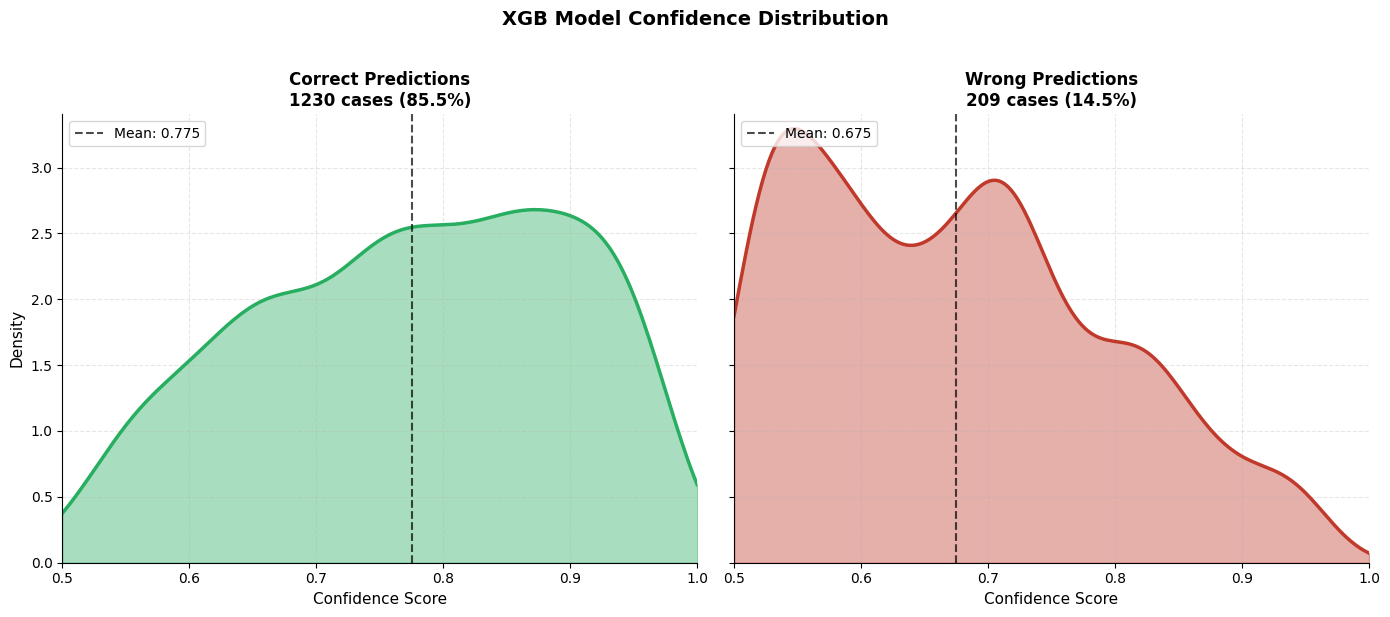

Correct: 1230 (85.5%)
Wrong:   209 (14.5%)


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

y_pred_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = xgb.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_pred_prob
})

results['Confidence'] = np.where(results['Probability'] > 0.5, 
                                  results['Probability'], 
                                  1 - results['Probability'])
results['Outcome'] = np.where(results['Actual'] == results['Predicted'], 'Correct', 'Wrong')

correct = results[results['Outcome'] == 'Correct']
wrong = results[results['Outcome'] == 'Wrong']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, subset, color, title in zip(axes, 
                                     [correct, wrong], 
                                     ['#27ae60', '#c0392b'],
                                     [f'Correct Predictions\n{len(correct)} cases ({len(correct)/len(results)*100:.1f}%)',
                                      f'Wrong Predictions\n{len(wrong)} cases ({len(wrong)/len(results)*100:.1f}%)']):
    
    data = subset['Confidence']
    
    if len(data) > 1:
        xs = np.linspace(0.5, 1, 200)
        kde = gaussian_kde(data)
        kde.covariance_factor = lambda: 0.25
        kde._compute_covariance()
        
        ax.fill_between(xs, kde(xs), alpha=0.4, color=color)
        ax.plot(xs, kde(xs), color=color, linewidth=2.5)
        
        mean_conf = data.mean()
        ax.axvline(mean_conf, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Mean: {mean_conf:.3f}')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Confidence Score', fontsize=11)
    ax.set_xlim(0.5, 1)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Density', fontsize=11)
plt.suptitle('XGB Model Confidence Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('XGB_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Correct: {len(correct)} ({len(correct)/len(results)*100:.1f}%)")
print(f"Wrong:   {len(wrong)} ({len(wrong)/len(results)*100:.1f}%)")